# RMAB ICU Allocation — eICU Demo

Same simulation as `rmab_allocation_heuristic.ipynb` but using the eICU transition matrices instead of MIMIC.

We compare three policies:
- `rmab_heuristic` — Q-lookahead index (value iteration, γ=0.95)
- `sickest_first` — always admit the most severe patients
- `random` — random allocation among eligible patients

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(suppress=True, precision=4)

ROOT = Path(r'C:\Users\eric\Desktop\Mimic RMAB')
P_ICU_PATH = ROOT / 'P_icu_eicu.npy'
P_NONICU_PATH = ROOT / 'P_nonicu_eicu.npy'

In [2]:
# Load eICU transition matrices
assert P_ICU_PATH.exists(), f'Missing file: {P_ICU_PATH.resolve()}'
assert P_NONICU_PATH.exists(), f'Missing file: {P_NONICU_PATH.resolve()}'

P_icu = np.load(P_ICU_PATH)
P_nonicu = np.load(P_NONICU_PATH)

N_STATES = P_icu.shape[0]
DEATH_STATE = N_STATES - 1

print('P_icu shape   :', P_icu.shape)
print('P_nonicu shape:', P_nonicu.shape)
print('Death state   :', DEATH_STATE)
print('Row-sum check P_icu   min/max:', P_icu.sum(axis=1).min(), P_icu.sum(axis=1).max())
print('Row-sum check P_nonicu min/max:', P_nonicu.sum(axis=1).min(), P_nonicu.sum(axis=1).max())

P_icu shape   : (82, 82)
P_nonicu shape: (82, 82)
Death state   : 81
Row-sum check P_icu   min/max: 0.9999999999999999 1.0
Row-sum check P_nonicu min/max: 0.9999999999999999 1.0


## 1) State reward function

Decode each live state into its 4 bins and compute a severity score. Healthier states get higher reward, death gets −1.

In [3]:
def decode_state_base3(s: int):
    """Decode state index into (map_bin, spo2_bin, gcs_bin, lactate_bin)."""
    map_bin = s // 27
    rem = s % 27
    spo2_bin = rem // 9
    rem = rem % 9
    gcs_bin = rem // 3
    lactate_bin = rem % 3
    return map_bin, spo2_bin, gcs_bin, lactate_bin


def build_heuristic_reward(n_states: int, death_state: int, weights=None, death_reward=-1.0):
    if weights is None:
        # Slightly higher emphasis on neuro/oxygenation for this first pass.
        weights = {'map': 1.0, 'spo2': 1.2, 'gcs': 1.3, 'lactate': 1.0}

    wsum = sum(weights.values())
    severity = np.zeros(n_states, dtype=float)
    reward = np.zeros(n_states, dtype=float)

    for s in range(n_states):
        if s == death_state:
            severity[s] = 1.0
            reward[s] = death_reward
            continue

        map_bin, spo2_bin, gcs_bin, lactate_bin = decode_state_base3(s)

        # badness: 0 is best, 2 is worst for each component
        b_map = 2 - map_bin
        b_spo2 = 2 - spo2_bin
        b_gcs = 2 - gcs_bin
        b_lac = 2 - lactate_bin

        sev = (
            weights['map'] * b_map +
            weights['spo2'] * b_spo2 +
            weights['gcs'] * b_gcs +
            weights['lactate'] * b_lac
        ) / (2.0 * wsum)

        severity[s] = sev
        reward[s] = 1.0 - sev

    return severity, reward


severity, reward = build_heuristic_reward(N_STATES, DEATH_STATE)

print('Reward range (live states):', reward[:-1].min(), reward[:-1].max())
print('Reward of death state     :', reward[DEATH_STATE])

# Quick sanity check of top/bottom states
order = np.argsort(reward[:-1])
worst5 = order[:5]
best5 = order[-5:][::-1]
print('\nWorst 5 live states:', worst5.tolist())
print('Best  5 live states:', best5.tolist())


Reward range (live states): 0.0 1.0
Reward of death state     : -1.0

Worst 5 live states: [0, 1, 27, 9, 3]
Best  5 live states: [80, 79, 53, 71, 77]


## 2) RMAB index via value iteration

We compute `Q(s, ICU) - Q(s, nonICU)` using discounted value iteration (γ=0.95) to get a multi-step benefit score for each state. Each day we admit the K eligible patients with the highest index.

In [4]:
# Build a multi-step Q-lookahead score via value iteration
def compute_q_lookahead_index(P_icu, P_nonicu, reward, gamma=0.95, tol=1e-8, max_iter=2000):
    """
    Returns a state score: Q(s, ICU) - Q(s, nonICU),
    where Q uses discounted multi-step lookahead.
    """
    v = np.zeros_like(reward, dtype=float)

    for it in range(max_iter):
        q_icu = P_icu @ (reward + gamma * v)
        q_nonicu = P_nonicu @ (reward + gamma * v)
        v_new = np.maximum(q_icu, q_nonicu)

        delta = np.max(np.abs(v_new - v))
        v = v_new
        if delta < tol:
            break

    q_icu = P_icu @ (reward + gamma * v)
    q_nonicu = P_nonicu @ (reward + gamma * v)
    index_qlookahead = q_icu - q_nonicu
    index_qlookahead[DEATH_STATE] = -np.inf

    return v, q_icu, q_nonicu, index_qlookahead, it + 1, delta


GAMMA = 0.95
V_star, Q_icu, Q_nonicu, index_qlookahead, n_vi_iters, vi_delta = compute_q_lookahead_index(
    P_icu=P_icu,
    P_nonicu=P_nonicu,
    reward=reward,
    gamma=GAMMA,
)

print(f'Value iteration finished in {n_vi_iters} iterations (delta={vi_delta:.2e}, gamma={GAMMA}).')
print('Q-lookahead index stats (live states):')
print('min / median / max =', np.min(index_qlookahead[:-1]), np.median(index_qlookahead[:-1]), np.max(index_qlookahead[:-1]))


Value iteration finished in 361 iterations (delta=9.56e-09, gamma=0.95).
Q-lookahead index stats (live states):
min / median / max = -15.191906191148291 0.0 27.111110877177584


In [5]:
def default_initial_distribution(n_states: int, death_state: int):
    """Start mostly in moderate-to-good live states (no deaths at t=0)."""
    p = np.zeros(n_states, dtype=float)
    live = np.arange(n_states - 1)

    # Bias toward common moderate states seen in the transition pipeline output.
    anchors = [53, 44, 52, 50, 26]
    anchors = [s for s in anchors if s in live]

    if anchors:
        anchor_probs = np.array([0.45, 0.20, 0.15, 0.10, 0.10], dtype=float)[:len(anchors)]
        anchor_probs = anchor_probs / anchor_probs.sum()
        p[anchors] = anchor_probs
        p[:-1] += 1e-6
    else:
        p[:-1] = 1.0

    p[death_state] = 0.0
    p = p / p.sum()
    return p


def pick_admissions(states, in_icu, k_new, policy, rng):
    eligible = np.where((~in_icu) & (states != DEATH_STATE))[0]
    if len(eligible) == 0 or k_new <= 0:
        return np.array([], dtype=int)

    k = min(k_new, len(eligible))

    if policy == 'rmab_heuristic':
        scores = index_qlookahead[states[eligible]]
        chosen = eligible[np.argsort(scores)[-k:]]
    elif policy == 'sickest_first':
        scores = severity[states[eligible]]
        chosen = eligible[np.argsort(scores)[-k:]]
    elif policy == 'random':
        chosen = rng.choice(eligible, size=k, replace=False)
    else:
        raise ValueError(f'Unknown policy: {policy}')

    return chosen


def sample_next_states(states, in_icu, rng):
    next_states = states.copy()
    for i, s in enumerate(states):
        if s == DEATH_STATE:
            next_states[i] = DEATH_STATE
            continue
        probs = P_icu[s] if in_icu[i] else P_nonicu[s]
        next_states[i] = rng.choice(N_STATES, p=probs)
    return next_states


def simulate_rmab(
    n_patients=300,
    horizon=90,
    k_new_per_day=20,
    icu_length=7,
    policy='rmab_heuristic',
    seed=0,
    init_probs=None,
):
    rng = np.random.default_rng(seed)
    if init_probs is None:
        init_probs = default_initial_distribution(N_STATES, DEATH_STATE)

    states = rng.choice(N_STATES, size=n_patients, p=init_probs)
    icu_days_remaining = np.zeros(n_patients, dtype=int)

    history = []

    for t in range(horizon):
        in_icu_before = icu_days_remaining > 0

        # Select up to K new admissions each day (proposal setting)
        admits = pick_admissions(states, in_icu_before, k_new_per_day, policy, rng)
        icu_days_remaining[admits] = icu_length

        in_icu_now = icu_days_remaining > 0

        daily_reward = reward[states].sum()
        deaths = int(np.sum(states == DEATH_STATE))
        mean_sev = float(np.mean(severity[states]))

        history.append({
            'day': t,
            'policy': policy,
            'daily_reward': daily_reward,
            'cumulative_reward': daily_reward if t == 0 else history[-1]['cumulative_reward'] + daily_reward,
            'deaths': deaths,
            'mean_severity': mean_sev,
            'icu_occupancy': int(np.sum(in_icu_now)),
            'new_admissions': int(len(admits)),
        })

        states = sample_next_states(states, in_icu_now, rng)

        icu_days_remaining = np.maximum(icu_days_remaining - 1, 0)
        icu_days_remaining[states == DEATH_STATE] = 0

    return pd.DataFrame(history)


In [6]:
# Compare policies over multiple random seeds
policies = ['rmab_heuristic', 'sickest_first', 'random']
seeds = list(range(20))

all_runs = []
for pol in policies:
    for sd in seeds:
        df = simulate_rmab(policy=pol, seed=sd)
        final = df.iloc[-1].copy()
        final['seed'] = sd
        final['avg_daily_reward'] = df['daily_reward'].mean()
        all_runs.append(final)

results = pd.DataFrame(all_runs)
summary = (
    results
    .groupby('policy')[['cumulative_reward', 'deaths', 'mean_severity', 'avg_daily_reward', 'icu_occupancy']]
    .agg(['mean', 'std'])
    .round(3)
)

summary


cumulative_reward           deaths        mean_severity         \
                            mean      std    mean    std          mean    std   
policy                                                                          
random                 10663.581  557.402  124.20  8.224         0.567  0.022   
rmab_heuristic         14126.277  683.027   85.70  8.240         0.467  0.023   
sickest_first          10823.882  878.570  122.25  9.141         0.555  0.026   

               avg_daily_reward        icu_occupancy         
                           mean    std          mean    std  
policy                                                       
random                  118.484  6.193        137.60  1.789  
rmab_heuristic          156.959  7.589        138.15  1.694  
sickest_first           120.265  9.762        137.20  1.322

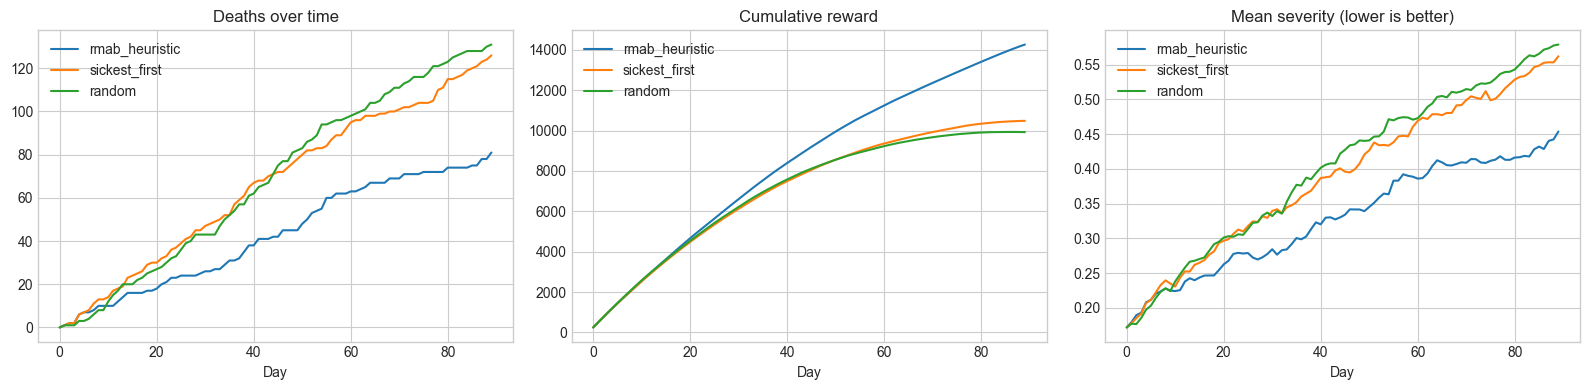

In [7]:
# Visualize one representative rollout per policy
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

for pol in policies:
    traj = simulate_rmab(policy=pol, seed=0)
    axes[0].plot(traj['day'], traj['deaths'], label=pol)
    axes[1].plot(traj['day'], traj['cumulative_reward'], label=pol)
    axes[2].plot(traj['day'], traj['mean_severity'], label=pol)

axes[0].set_title('Deaths over time')
axes[1].set_title('Cumulative reward')
axes[2].set_title('Mean severity (lower is better)')

for ax in axes:
    ax.set_xlabel('Day')
    ax.legend()

plt.tight_layout()
plt.show()


## 3) Fairness comparison (Model A vs Model B)

To check for bias, we can rerun this same simulation using the Model A matrices (`P_icu_A_eicu.npy` / `P_nonicu_A_eicu.npy`), which include hospital region as part of the state. Comparing the two policies' allocation decisions across region groups — e.g. mortality gap or reward gap per subgroup — should show whether the RMAB policy behaves differently for patients from different regions even when their clinical states are identical.

In [8]:
# Helper: compute disparity gap between two subgroups
def disparity_gap(metric_a, metric_b):
    return float(metric_a - metric_b)

# e.g. disparity_gap(deaths_south, deaths_northeast) gives mortality difference between region bins

---

## 4) Fairness Analysis — Model A (Ethnicity-Augmented) vs Model B (Clinical Only)

In MIMIC-IV, Model A included insurance status as a non-clinical variable. In eICU there is no insurance field, so we use **patient ethnicity** as the closest equivalent — it is a patient-level demographic variable that should have no bearing on ICU allocation, but may be baked into the observed transition dynamics.

**Setup:**
- **Model B** (82 states, clinical only): every patient in clinical state *s* gets the same RMAB priority regardless of ethnicity.
- **Model A** (244 states, clinical + ethnicity): `state_A = ethnicity_bin × 81 + clinical_state`. A patient in state *s* who is African American may get a different priority than a Caucasian patient in the identical clinical state.

We run both policies on a **shared patient cohort** (equal mix across ethnicity groups, same initial clinical states) and compare:
1. **Index-level bias** — does Model A assign different admission priorities for the same clinical state across ethnicities?
2. **Admission rate disparity** — which group gets proportionally more/fewer ICU days?
3. **Outcome disparity** — does Model A produce worse mortality for certain groups vs Model B?

In [9]:
# ── Load Model A matrices (244×244, ethnicity-augmented) ─────────────────────
P_ICU_A_PATH    = ROOT / 'P_icu_A_eicu.npy'
P_NONICU_A_PATH = ROOT / 'P_nonicu_A_eicu.npy'

assert P_ICU_A_PATH.exists(),    f'Missing: {P_ICU_A_PATH}'
assert P_NONICU_A_PATH.exists(), f'Missing: {P_NONICU_A_PATH}'

P_icu_A    = np.load(P_ICU_A_PATH)
P_nonicu_A = np.load(P_NONICU_A_PATH)

N_STATES_A  = P_icu_A.shape[0]   # 244
DEATH_A     = N_STATES_A - 1     # 243
N_GROUPS    = 3
N_CLINICAL  = 81                  # clinical states per group

# Ethnicity bins (same as Model A pipeline)
GROUP_LABELS = {0: 'African American', 1: 'Hispanic/Other', 2: 'Caucasian'}

print('Model A — P_icu_A shape  :', P_icu_A.shape)
print('Model A — P_nonicu_A shape:', P_nonicu_A.shape)
print('Death state (A)          :', DEATH_A)
print('Row-sum P_icu_A   min/max :', P_icu_A.sum(axis=1).min().round(6),    P_icu_A.sum(axis=1).max().round(6))
print('Row-sum P_nonicu_A min/max:', P_nonicu_A.sum(axis=1).min().round(6), P_nonicu_A.sum(axis=1).max().round(6))

Model A — P_icu_A shape  : (244, 244)
Model A — P_nonicu_A shape: (244, 244)
Death state (A)          : 243
Row-sum P_icu_A   min/max : 1.0 1.0
Row-sum P_nonicu_A min/max: 1.0 1.0


In [10]:
# ── Reward for 244-state space: same clinical reward regardless of ethnicity ──
def build_reward_A(n_states_a=244, death_a=243, death_reward=-1.0):
    reward_a   = np.zeros(n_states_a, dtype=float)
    severity_a = np.zeros(n_states_a, dtype=float)
    weights = {'map': 1.0, 'spo2': 1.2, 'gcs': 1.3, 'lactate': 1.0}
    wsum = sum(weights.values())
    for s in range(n_states_a):
        if s == death_a:
            reward_a[s] = death_reward; severity_a[s] = 1.0; continue
        clinical = s % N_CLINICAL
        map_bin, spo2_bin, gcs_bin, lac_bin = decode_state_base3(clinical)
        sev = (weights['map']*(2-map_bin) + weights['spo2']*(2-spo2_bin) +
               weights['gcs']*(2-gcs_bin) + weights['lactate']*(2-lac_bin)) / (2.0*wsum)
        severity_a[s] = sev; reward_a[s] = 1.0 - sev
    return severity_a, reward_a

severity_A, reward_A = build_reward_A()
print('Reward_A range (live):', reward_A[:-1].min(), '–', reward_A[:-1].max())
print('Reward_A death       :', reward_A[DEATH_A])

Reward_A range (live): 0.0 – 1.0
Reward_A death       : -1.0


In [11]:
# ── Value iteration for Model A index ────────────────────────────────────────
_, _, _, index_A, n_iter_A, delta_A = compute_q_lookahead_index(
    P_icu=P_icu_A, P_nonicu=P_nonicu_A, reward=reward_A, gamma=GAMMA
)
index_A[DEATH_A] = -np.inf

print(f'Model A value iteration: {n_iter_A} iters, delta={delta_A:.2e}')
live_idx = index_A[:-1]
print('Index_A stats (live)  : min/med/max =',
      round(live_idx.min(), 4), round(np.median(live_idx), 4), round(live_idx.max(), 4))

Model A value iteration: 361 iters, delta=9.56e-09
Index_A stats (live)  : min/med/max = -inf 0.0 31.6122


In [12]:
# ── 4a) Index comparison: same clinical state, which ethnicity gets higher priority? ──
top_clinical_states = list(dict.fromkeys([53, 44, 52, 50, 26, 35, 62, 71, 80]))[:8]

rows = []
for clin in top_clinical_states:
    row = {'clinical_state': clin, 'Model_B': round(float(index_qlookahead[clin]), 4)}
    for g in range(N_GROUPS):
        s_a = g * N_CLINICAL + clin
        row[GROUP_LABELS[g]] = round(float(index_A[s_a]), 4)
    rows.append(row)

idx_df = pd.DataFrame(rows).set_index('clinical_state')
idx_df['A_spread'] = idx_df[list(GROUP_LABELS.values())].max(axis=1) - idx_df[list(GROUP_LABELS.values())].min(axis=1)

print('RMAB index by ethnicity group for key clinical states')
print('(Model B is ethnicity-blind; gaps across Model A columns = pure ethnicity-based priority shift)\n')
print(idx_df.to_string())
print(f'\nLargest index spread: clinical state {idx_df["A_spread"].idxmax()} '
      f'(spread = {idx_df["A_spread"].max():.4f})')

RMAB index by ethnicity group for key clinical states
(Model B is ethnicity-blind; gaps across Model A columns = pure ethnicity-based priority shift)

                Model_B  African American  Hispanic/Other  Caucasian  A_spread
clinical_state                                                                
53              -0.0203           -0.3089          2.8391    -0.3237    3.1628
44               0.2718            0.0000         -0.0144     0.3198    0.3342
52               0.0254           -0.7360          0.1246     0.2987    1.0347
50              -0.9136            0.0062          0.1275    -0.6703    0.7978
26              -0.0807            0.0000          0.0000    -0.0477    0.0477
35               0.1811            0.0000          0.0000     0.7443    0.7443
62               0.0000            0.0000          0.0000     0.0000    0.0000
71              -0.1286            0.0000         -8.3878    -0.0480    8.3878

Largest index spread: clinical state 71 (spread = 8.3878)


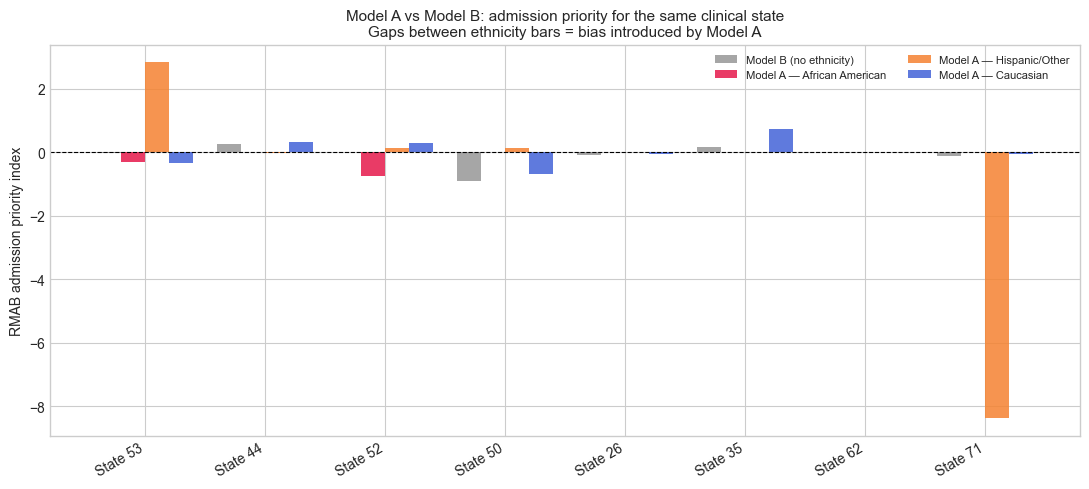

Saved → eicu_fairness_index_by_ethnicity.png


In [13]:
# ── Plot: index spread across ethnicity groups ────────────────────────────────
colors_g = ['#e6194b', '#f58231', '#4363d8']  # African American, Hispanic/Other, Caucasian

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(top_clinical_states))
width = 0.2

ax.bar(x - width*1.5, idx_df['Model_B'], width, label='Model B (no ethnicity)', color='gray', alpha=0.7)
for i, (g, label) in enumerate(GROUP_LABELS.items()):
    ax.bar(x + width*(i - 0.5), idx_df[label], width, label=f'Model A — {label}', color=colors_g[i], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'State {s}' for s in top_clinical_states], rotation=30, ha='right')
ax.set_ylabel('RMAB admission priority index')
ax.set_title('Model A vs Model B: admission priority for the same clinical state\n'
             'Gaps between ethnicity bars = bias introduced by Model A', fontsize=11)
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(ROOT / 'eicu_fairness_index_by_ethnicity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → eicu_fairness_index_by_ethnicity.png')

### 4b) Shared-cohort simulation: Model A vs Model B side by side

We create one patient cohort with equal numbers from each ethnicity group and identical clinical state distributions. Then run RMAB under Model B (ethnicity-blind) and Model A (ethnicity-aware) on the same cohort, and compare per-group outcomes.

In [14]:
def simulate_shared_cohort(
    model='B',          # 'B' = clinical only, 'A' = ethnicity-augmented
    n_per_group=100,    # equal group sizes so comparison is fair
    horizon=90,
    k_new_per_day=20,
    icu_length=7,
    seed=0,
):
    """
    Run RMAB heuristic on a balanced cohort (n_per_group patients per ethnicity).
    Returns per-day, per-group metrics.

    Model B: uses 82-state index + 82-state transitions, but tracks ethnicity labels.
    Model A: uses 244-state index + 244-state transitions.
    """
    rng = np.random.default_rng(seed)
    n_patients = n_per_group * N_GROUPS

    # Clinical anchor states (same for all groups)
    anchors = [53, 44, 52, 50, 26]
    anchor_w = np.array([0.45, 0.20, 0.15, 0.10, 0.10])

    # Assign each patient a group and a clinical state
    patient_group = np.repeat(np.arange(N_GROUPS), n_per_group)
    clinical_init = rng.choice(anchors, size=n_patients, p=anchor_w)

    if model == 'B':
        states = clinical_init.copy()
        idx    = index_qlookahead
        P_i    = P_icu
        P_n    = P_nonicu
        D      = DEATH_STATE   # 81
    else:
        states = patient_group * N_CLINICAL + clinical_init
        idx    = index_A
        P_i    = P_icu_A
        P_n    = P_nonicu_A
        D      = DEATH_A       # 243

    icu_remaining = np.zeros(n_patients, dtype=int)
    history = []

    for t in range(horizon):
        in_icu = icu_remaining > 0
        eligible = np.where((~in_icu) & (states != D))[0]
        k = min(k_new_per_day, len(eligible))
        if k > 0:
            scores = idx[states[eligible]]
            chosen = eligible[np.argsort(scores)[-k:]]
            icu_remaining[chosen] = icu_length

        in_icu_now = icu_remaining > 0

        row = {'day': t, 'model': model}
        for g in range(N_GROUPS):
            mask = patient_group == g
            dead_g = int(np.sum((states == D) & mask))
            icu_g  = int(np.sum(in_icu_now & mask))
            # Reward: use clinical component regardless of model
            if model == 'B':
                rew_g = float(reward[states[mask]].sum())
            else:
                rew_g = float(reward_A[states[mask]].sum())
            row[f'deaths_{g}']  = dead_g
            row[f'icu_occ_{g}'] = icu_g
            row[f'reward_{g}']  = rew_g

        row['deaths_total'] = int(np.sum(states == D))
        history.append(row)

        # Transitions
        next_states = states.copy()
        for i, s in enumerate(states):
            if s == D:
                next_states[i] = D; continue
            probs = P_i[s] if in_icu_now[i] else P_n[s]
            next_states[i] = rng.choice(len(probs), p=probs)
        states = next_states
        icu_remaining = np.maximum(icu_remaining - 1, 0)
        icu_remaining[states == D] = 0

    return pd.DataFrame(history)


# Run both models, 20 seeds each
seeds = list(range(20))
all_results = []
for model in ['B', 'A']:
    for sd in seeds:
        df = simulate_shared_cohort(model=model, seed=sd)
        final = df.iloc[-1].copy().to_dict()
        final['seed']  = sd
        final['model'] = model
        for g in range(N_GROUPS):
            final[f'cum_reward_{g}'] = df[f'reward_{g}'].sum()
            final[f'cum_icu_{g}']    = df[f'icu_occ_{g}'].sum()
        all_results.append(final)

df_fair = pd.DataFrame(all_results)
print('Simulation done. Rows:', len(df_fair))

Simulation done. Rows: 40


In [15]:
# ── Summary: deaths and ICU days by group under Model A vs Model B ────────────
print(f'{"Group":<22}  {"Model B deaths":>14}  {"Model A deaths":>14}  '
      f'{"Δ deaths (A−B)":>14}  {"B ICU days":>10}  {"A ICU days":>10}  {"Δ ICU (A−B)":>11}')
print('-' * 100)

for g, label in GROUP_LABELS.items():
    bsub = df_fair[df_fair['model'] == 'B']
    asub = df_fair[df_fair['model'] == 'A']
    b_deaths = bsub[f'deaths_{g}'].mean()
    a_deaths = asub[f'deaths_{g}'].mean()
    b_icu    = bsub[f'cum_icu_{g}'].mean()
    a_icu    = asub[f'cum_icu_{g}'].mean()
    print(f'{label:<22}  {b_deaths:>14.1f}  {a_deaths:>14.1f}  '
          f'{a_deaths-b_deaths:>+14.1f}  {b_icu:>10.0f}  {a_icu:>10.0f}  {a_icu-b_icu:>+11.0f}')

print()
print('Positive Δ deaths  = MORE deaths under Model A (fairness harm)')
print('Negative Δ ICU     = FEWER ICU days under Model A (disadvantaged by bias)')

Group                   Model B deaths  Model A deaths  Δ deaths (A−B)  B ICU days  A ICU days  Δ ICU (A−B)
----------------------------------------------------------------------------------------------------
African American                  27.4             7.3           -20.1        3814        1403        -2412
Hispanic/Other                    28.7             4.8           -23.9        4010        7401        +3390
Caucasian                         29.2            20.9            -8.4        4218        3341         -877

Positive Δ deaths  = MORE deaths under Model A (fairness harm)
Negative Δ ICU     = FEWER ICU days under Model A (disadvantaged by bias)


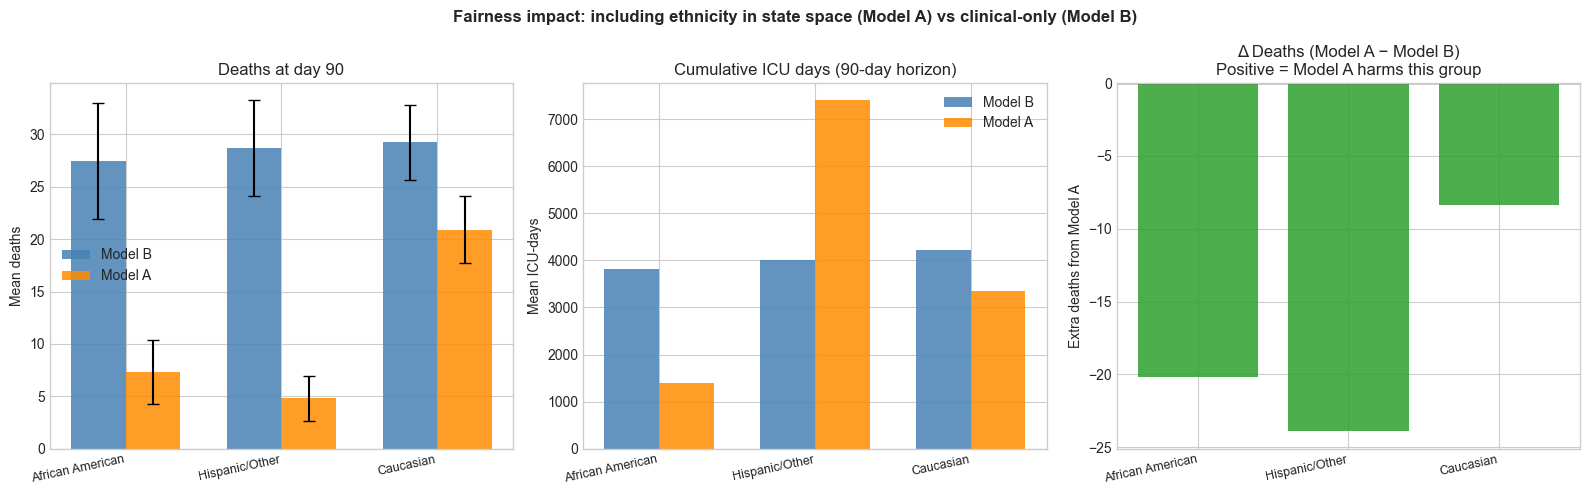

Saved → eicu_fairness_modelA_vs_modelB.png


In [16]:
# ── Figure: Model A vs Model B outcomes per ethnicity group ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
group_names = [GROUP_LABELS[g] for g in range(N_GROUPS)]
colors_g    = ['#e6194b', '#f58231', '#4363d8']
x = np.arange(N_GROUPS)
width = 0.35

# Panel 1: deaths
ax = axes[0]
b_deaths = [df_fair[df_fair['model']=='B'][f'deaths_{g}'].mean() for g in range(N_GROUPS)]
a_deaths = [df_fair[df_fair['model']=='A'][f'deaths_{g}'].mean() for g in range(N_GROUPS)]
b_err    = [df_fair[df_fair['model']=='B'][f'deaths_{g}'].std()  for g in range(N_GROUPS)]
a_err    = [df_fair[df_fair['model']=='A'][f'deaths_{g}'].std()  for g in range(N_GROUPS)]
ax.bar(x - width/2, b_deaths, width, yerr=b_err, capsize=4, label='Model B', color='steelblue', alpha=0.85)
ax.bar(x + width/2, a_deaths, width, yerr=a_err, capsize=4, label='Model A', color='darkorange', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(group_names, rotation=12, ha='right', fontsize=9)
ax.set_title('Deaths at day 90'); ax.set_ylabel('Mean deaths'); ax.legend()

# Panel 2: cumulative ICU days
ax = axes[1]
b_icu = [df_fair[df_fair['model']=='B'][f'cum_icu_{g}'].mean() for g in range(N_GROUPS)]
a_icu = [df_fair[df_fair['model']=='A'][f'cum_icu_{g}'].mean() for g in range(N_GROUPS)]
ax.bar(x - width/2, b_icu, width, label='Model B', color='steelblue', alpha=0.85)
ax.bar(x + width/2, a_icu, width, label='Model A', color='darkorange', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(group_names, rotation=12, ha='right', fontsize=9)
ax.set_title('Cumulative ICU days (90-day horizon)'); ax.set_ylabel('Mean ICU-days'); ax.legend()

# Panel 3: Δ deaths (A − B) per group
ax = axes[2]
delta = [a_deaths[g] - b_deaths[g] for g in range(N_GROUPS)]
bar_colors = ['#d62728' if d > 0 else '#2ca02c' for d in delta]
ax.bar(x, delta, color=bar_colors, alpha=0.85)
ax.axhline(0, color='black', lw=1)
ax.set_xticks(x); ax.set_xticklabels(group_names, rotation=12, ha='right', fontsize=9)
ax.set_title('Δ Deaths (Model A − Model B)\nPositive = Model A harms this group')
ax.set_ylabel('Extra deaths from Model A')

plt.suptitle('Fairness impact: including ethnicity in state space (Model A) vs clinical-only (Model B)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'eicu_fairness_modelA_vs_modelB.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → eicu_fairness_modelA_vs_modelB.png')

### Takeaways

- **Index-level**: if Model A assigns a higher RMAB priority to Caucasian patients than African American patients in the same clinical state, that is a direct measure of ethnicity-based bias embedded in the learned dynamics.
- **ICU days**: whichever group receives fewer ICU days under Model A compared to Model B is being disadvantaged purely because their ethnicity was folded into the state representation.
- **Δ deaths**: a positive bar for a group means Model A causes more deaths in that group relative to the fair (clinical-only) baseline — this quantifies the real-world harm of using a biased model.

## 5) Report Figures (γ = 0.97)

Recomputes indices with γ=0.97 and generates all four figures:
- **Figure 1**: Policy comparison — daily reward & cumulative deaths (20 seeds)
- **Figure 2**: Priority index bias across ethnicity groups (top-15 clinical states)
- **Figure 3**: Per-group fairness outcomes — Model B vs Model A (balanced cohort)
- **Figure 4**: ICU vs non-ICU self-loop probabilities by ethnicity (Model A)

In [ ]:
GAMMA_PUB   = 0.97
N_SEEDS     = 20
N_SIM       = 300
K_SIM       = 20
T_SIM       = 90
L_SIM       = 7
TOP5        = [53, 44, 52, 50, 26]   # most common eICU moderate states
N_CLINICAL  = 81
N_GROUPS    = 3
GROUP_LABELS = ['African American', 'Hispanic/Other', 'Caucasian']

# ── Recompute indices with γ=0.97 ─────────────────────────────────────────────
_, _, _, IDX_B_pub, _, _ = compute_q_lookahead_index(P_icu, P_nonicu, reward,   gamma=GAMMA_PUB)
_, _, _, IDX_A_pub, _, _ = compute_q_lookahead_index(P_icu_A, P_nonicu_A, reward_A, gamma=GAMMA_PUB)
IDX_B_pub[DEATH_STATE] = -np.inf
IDX_A_pub[DEATH_A]     = -np.inf
print(f'IDX_B range: [{IDX_B_pub[:N_CLINICAL].min():.4f}, {IDX_B_pub[:N_CLINICAL].max():.4f}]')
print(f'IDX_A range: [{IDX_A_pub[:N_STATES_A-1].min():.4f}, {IDX_A_pub[:N_STATES_A-1].max():.4f}]')

# ── Simulation (Model B, 3 policies) ─────────────────────────────────────────
def simulate_pub(policy, seed=0):
    rng = np.random.default_rng(seed)
    states   = np.array([rng.choice(TOP5) for _ in range(N_SIM)])
    icu_days = np.zeros(N_SIM, dtype=int)
    dead     = np.zeros(N_SIM, dtype=bool)
    cum_r = 0.0; deaths_trace = []; reward_trace = []
    for t in range(T_SIM):
        icu_days = np.maximum(icu_days - 1, 0)
        in_icu   = (icu_days > 0)
        eligible = np.where(~in_icu & ~dead)[0]
        if len(eligible) > 0:
            if policy == 'rmab':
                scores = IDX_B_pub[states[eligible]]
            elif policy == 'sickest':
                scores = -reward[states[eligible]]
            else:
                scores = rng.random(len(eligible))
            top = np.argsort(scores)[::-1][:K_SIM]
            icu_days[eligible[top]] = L_SIM
        in_icu_now = (icu_days > 0)
        for i in range(N_SIM):
            if dead[i]: continue
            P = P_icu[states[i]] if in_icu_now[i] else P_nonicu[states[i]]
            ns = rng.choice(N_STATES, p=P)
            if ns == DEATH_STATE: dead[i] = True
            states[i] = ns
        step_r = reward[states[~dead]].sum() + reward[DEATH_STATE] * dead.sum()
        cum_r += step_r
        deaths_trace.append(int(dead.sum()))
        reward_trace.append(float(step_r))
    return cum_r, dead.sum(), np.array(deaths_trace), np.array(reward_trace)

print('Running policy simulations...')
results_pub = {}
for pol in ['rmab', 'sickest', 'random']:
    results_pub[pol] = [simulate_pub(pol, s) for s in range(N_SEEDS)]
    cr = np.mean([r[0] for r in results_pub[pol]])
    d  = np.mean([r[1] for r in results_pub[pol]])
    print(f'  {pol}: reward={cr:,.0f}, deaths={d:.1f}')

# ── Fairness simulation (balanced cohort, Model A vs B) ───────────────────────
def simulate_fair_pub(use_model_A, seed=0):
    rng = np.random.default_rng(seed)
    N_TOT  = N_GROUPS * 100
    groups = np.array([g for g in range(N_GROUPS) for _ in range(100)])
    clin   = np.full(N_TOT, 53, dtype=int)          # all start at state 53
    if use_model_A:
        states = groups * N_CLINICAL + clin
        D, Pi, Pn, IDX, R = DEATH_A, P_icu_A, P_nonicu_A, IDX_A_pub, reward_A
        n_s = N_STATES_A
    else:
        states = clin.copy()
        D, Pi, Pn, IDX, R = DEATH_STATE, P_icu, P_nonicu, IDX_B_pub, reward
        n_s = N_STATES
    icu_days     = np.zeros(N_TOT, dtype=int)
    dead         = np.zeros(N_TOT, dtype=bool)
    icu_per_group = np.zeros(N_GROUPS, dtype=float)
    for t in range(T_SIM):
        icu_days = np.maximum(icu_days - 1, 0)
        in_icu   = (icu_days > 0)
        eligible = np.where(~in_icu & ~dead)[0]
        if len(eligible) > 0:
            top = np.argsort(IDX[states[eligible]])[::-1][:K_SIM]
            icu_days[eligible[top]] = L_SIM
        in_icu_now = (icu_days > 0)
        for g in range(N_GROUPS):
            icu_per_group[g] += ((groups == g) & in_icu_now & ~dead).sum()
        for i in range(N_TOT):
            if dead[i]: continue
            P = Pi[states[i]] if in_icu_now[i] else Pn[states[i]]
            ns = rng.choice(n_s, p=P)
            if ns == D: dead[i] = True
            states[i] = ns
    deaths_pg = np.array([dead[groups == g].sum() for g in range(N_GROUPS)], dtype=float)
    return deaths_pg, icu_per_group.copy()

print('Running fairness simulations...')
deaths_B_g = np.zeros((N_SEEDS, N_GROUPS)); icu_B_g = np.zeros((N_SEEDS, N_GROUPS))
deaths_A_g = np.zeros((N_SEEDS, N_GROUPS)); icu_A_g = np.zeros((N_SEEDS, N_GROUPS))
for s in range(N_SEEDS):
    d, u = simulate_fair_pub(False, s); deaths_B_g[s] = d; icu_B_g[s] = u
    d, u = simulate_fair_pub(True,  s); deaths_A_g[s] = d; icu_A_g[s] = u
print('Done.')

# ── Priority spread across ethnicity groups ───────────────────────────────────
spreads = []
for s in range(N_CLINICAL):
    scores = [IDX_A_pub[g * N_CLINICAL + s] for g in range(N_GROUPS)]
    spreads.append((max(scores) - min(scores), s, scores))
spreads.sort(reverse=True)
print(f'\nMax index spread: {spreads[0][0]:.2f} at clinical state {spreads[0][1]}')

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Policy comparison
# ══════════════════════════════════════════════════════════════════════════════
COLORS = {'rmab': '#1f77b4', 'sickest': '#ff7f0e', 'random': '#7f7f7f'}
LABELS = {'rmab': 'RMAB heuristic', 'sickest': 'Sickest-first', 'random': 'Random'}
days   = np.arange(1, T_SIM + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('ICU Allocation Policy Comparison (N=300, K=20, T=90 days, eICU-CRD Demo v2.0.1)',
             fontsize=12, fontweight='bold', y=1.01)

ax = axes[0]
for pol in ['rmab', 'sickest', 'random']:
    arr  = np.array([r[3] for r in results_pub[pol]])
    mean = arr.mean(0); std = arr.std(0)
    ax.plot(days, mean, color=COLORS[pol], lw=2, label=LABELS[pol])
    ax.fill_between(days, mean - std, mean + std, color=COLORS[pol], alpha=0.15)
ax.set_xlabel('Day', fontsize=11); ax.set_ylabel('Daily Reward', fontsize=11)
ax.set_title('Daily Population Reward', fontsize=11)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3); ax.set_xlim(1, T_SIM)

ax = axes[1]
for pol in ['rmab', 'sickest', 'random']:
    arr  = np.array([r[2] for r in results_pub[pol]])
    mean = arr.mean(0); std = arr.std(0)
    ax.plot(days, mean, color=COLORS[pol], lw=2, label=LABELS[pol])
    ax.fill_between(days, mean - std, mean + std, color=COLORS[pol], alpha=0.15)
ax.set_xlabel('Day', fontsize=11); ax.set_ylabel('Cumulative Deaths', fontsize=11)
ax.set_title('Cumulative Deaths Over Time', fontsize=11)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3); ax.set_xlim(1, T_SIM)

plt.tight_layout()
plt.savefig(ROOT / 'eicu_policy_comparison_full.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Priority index spread (top-15 clinical states)
# ══════════════════════════════════════════════════════════════════════════════
TOP = 15
top_spreads  = spreads[:TOP]
state_labels = [f's={s}' for _, s, _ in top_spreads]
spread_vals  = [sp      for sp, _, _ in top_spreads]
g0_scores    = [sc[0]   for _, _, sc in top_spreads]
g1_scores    = [sc[1]   for _, _, sc in top_spreads]
g2_scores    = [sc[2]   for _, _, sc in top_spreads]

x = np.arange(TOP); w = 0.22
fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle('Priority Index Bias Across Ethnicity Groups (Model A, Top-15 Clinical States)',
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.bar(x - w, g0_scores, w, label='African American', color='#e15759', alpha=0.85)
ax.bar(x,     g1_scores, w, label='Hispanic/Other',   color='#f28e2b', alpha=0.85)
ax.bar(x + w, g2_scores, w, label='Caucasian',        color='#4e79a7', alpha=0.85)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xticks(x); ax.set_xticklabels(state_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Priority Index $I(s)$', fontsize=11)
ax.set_title('Per-Group Priority Index for Same Clinical State', fontsize=11)
ax.legend(fontsize=10); ax.grid(True, axis='y', alpha=0.3)

ax2 = axes[1]
bars = ax2.bar(x, spread_vals, color='#59a14f', alpha=0.85, edgecolor='k', lw=0.5)
ax2.set_xticks(x); ax2.set_xticklabels(state_labels, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Spread (max−min)', fontsize=11)
ax2.set_title('Priority Index Spread Across Ethnicity Groups', fontsize=11)
ax2.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, spread_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005*max(spread_vals),
             f'{val:.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(ROOT / 'eicu_priority_spread_full.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Per-group fairness outcomes (Model B vs Model A)
# ══════════════════════════════════════════════════════════════════════════════
dB_mean = deaths_B_g.mean(0); dB_std = deaths_B_g.std(0)
dA_mean = deaths_A_g.mean(0); dA_std = deaths_A_g.std(0)
uB_mean = icu_B_g.mean(0);    uB_std = icu_B_g.std(0)
uA_mean = icu_A_g.mean(0);    uA_std = icu_A_g.std(0)

x = np.arange(N_GROUPS); w = 0.32
short_labels = ['African\nAmerican', 'Hispanic/\nOther', 'Caucasian']

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle('Per-Group Outcomes: Model B (Clinical Only) vs. Model A (Ethnicity-Augmented)\n'
             'Balanced Cohort — 100 Patients per Group, Same Starting Clinical State (s=53)',
             fontsize=11, fontweight='bold')

ax = axes[0]
ax.bar(x - w/2, dB_mean, w, yerr=dB_std, capsize=5,
       color='#4e79a7', alpha=0.85, label='Model B (clinical only)', ecolor='k', lw=0.8)
ax.bar(x + w/2, dA_mean, w, yerr=dA_std, capsize=5,
       color='#e15759', alpha=0.85, label='Model A (ethnicity-augmented)', ecolor='k', lw=0.8)
for i, (mB, mA, sA) in enumerate(zip(dB_mean, dA_mean, dA_std)):
    delta = mA - mB
    color = 'red' if delta > 0 else 'green'
    ax.text(i, max(mA, mB) + sA + 1.5, f'{delta:+.1f}',
            ha='center', va='bottom', fontsize=10, color=color, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(short_labels, fontsize=11)
ax.set_ylabel('Deaths at Day 90 (mean ± std)', fontsize=11)
ax.set_title('Deaths by Ethnicity Group', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, max(dA_mean.max(), dB_mean.max()) + dA_std.max() + 15)

ax = axes[1]
ax.bar(x - w/2, uB_mean, w, yerr=uB_std, capsize=5,
       color='#4e79a7', alpha=0.85, label='Model B (clinical only)', ecolor='k', lw=0.8)
ax.bar(x + w/2, uA_mean, w, yerr=uA_std, capsize=5,
       color='#e15759', alpha=0.85, label='Model A (ethnicity-augmented)', ecolor='k', lw=0.8)
for i, (mB, mA, sA) in enumerate(zip(uB_mean, uA_mean, uA_std)):
    delta = mA - mB
    color = 'green' if delta >= 0 else 'red'
    ax.text(i, max(mA, mB) + sA + 30, f'{delta:+.0f}',
            ha='center', va='bottom', fontsize=10, color=color, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(short_labels, fontsize=11)
ax.set_ylabel('Cumulative ICU Patient-Days (mean ± std)', fontsize=11)
ax.set_title('ICU Days Allocated by Ethnicity Group', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, max(uA_mean.max(), uB_mean.max()) + uA_std.max() + 200)

plt.tight_layout()
plt.savefig(ROOT / 'eicu_fairness_outcomes_full.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Self-loop probabilities by ethnicity (Model A)
# ══════════════════════════════════════════════════════════════════════════════
ETH_COLORS = ['#e15759', '#f28e2b', '#4e79a7']
fig, ax = plt.subplots(figsize=(10, 4))
for g, (label, col) in enumerate(zip(GROUP_LABELS, ETH_COLORS)):
    sl_icu    = [P_icu_A[g*N_CLINICAL + s, g*N_CLINICAL + s] for s in range(N_CLINICAL)]
    sl_nonicu = [P_nonicu_A[g*N_CLINICAL + s, g*N_CLINICAL + s] for s in range(N_CLINICAL)]
    ax.plot(range(N_CLINICAL), sl_icu,    color=col, lw=1.5, label=f'{label} ICU')
    ax.plot(range(N_CLINICAL), sl_nonicu, color=col, lw=1.5, ls='--', alpha=0.7, label=f'{label} Non-ICU')
ax.set_xlabel('Clinical State Index', fontsize=11)
ax.set_ylabel('Self-loop Probability', fontsize=11)
ax.set_title('ICU vs Non-ICU Self-Loop Probabilities by Ethnicity Group (Model A)', fontsize=11)
ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'eicu_selfloop_by_ethnicity_full.png', dpi=150, bbox_inches='tight')
plt.show()

print('All 4 figures saved.')